## **Exploratory Data Analysis**

This notebook aims to find patterns, trends and anything noteworthy about the data being used. Preprocessing will also be done in this notebook for use in training the machine learning models.

In [22]:
#Importing the necessary libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [23]:
data = yf.download("SPY", start = "2014-12-27", end = "2026-02-10")

[*********************100%***********************]  1 of 1 completed


In [24]:
data

Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2014-12-29,172.405457,172.611960,171.926367,171.992450,79643900
2014-12-30,171.480301,172.116322,171.405950,171.984169,73540800
2014-12-31,169.778717,171.967659,169.654820,171.802459,130333800
2015-01-02,169.687881,170.885611,168.655365,170.472604,121465900
2015-01-05,166.623352,168.812282,166.317731,168.647081,169632600
...,...,...,...,...,...
2026-02-03,685.885010,693.275726,680.414084,692.529690,107904600
2026-02-04,682.562683,687.794888,678.156108,686.700666,105204600


Let's change the order so that open is the first column:

In [25]:
prices = data[["Open", "High", "Low", "Close", "Volume"]].copy()

In [26]:
prices

Price,Open,High,Low,Close,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2014-12-29,171.992450,172.611960,171.926367,172.405457,79643900
2014-12-30,171.984169,172.116322,171.405950,171.480301,73540800
2014-12-31,171.802459,171.967659,169.654820,169.778717,130333800
2015-01-02,170.472604,170.885611,168.655365,169.687881,121465900
2015-01-05,168.647081,168.812282,166.317731,166.623352,169632600
...,...,...,...,...,...
2026-02-03,692.529690,693.275726,680.414084,685.885010,107904600
2026-02-04,686.700666,687.794888,678.156108,682.562683,105204600


Create a returns column:

In [27]:
prices["log_return"] = np.log(prices["Close"] / prices["Close"].shift(1))

In [28]:
prices

Price,Open,High,Low,Close,Volume,log_return
Ticker,SPY,SPY,SPY,SPY,SPY,
Date,,,,,,
2014-12-29,171.992450,172.611960,171.926367,172.405457,79643900,NaN
2014-12-30,171.984169,172.116322,171.405950,171.480301,73540800,-0.005381
2014-12-31,171.802459,171.967659,169.654820,169.778717,130333800,-0.009972
2015-01-02,170.472604,170.885611,168.655365,169.687881,121465900,-0.000535
2015-01-05,168.647081,168.812282,166.317731,166.623352,169632600,-0.018225
...,...,...,...,...,...,...
2026-02-03,692.529690,693.275726,680.414084,685.885010,107904600,-0.008491
2026-02-04,686.700666,687.794888,678.156108,682.562683,105204600,-0.004856


We need to create our target variable which is volatility. Volatility in finance is commonly measured using standard deviation, so thats what we'll use.

**What exactly is standard deviation?**
- Standard deviation is a measure of how far off a figure/measurement is from the mean 
- It's the sqaure root of the variance 

**Very helpful. What's the variance?**
- Variance is the average of the sqaured differences from the mean.

So in short we calculate the mean, square the differences then find the average (variance) -> sqaure root that figure (standard deviation) 

We will create a rolling future volatility target:

In [29]:
prices["future_vol_5"] = (prices["log_return"].rolling(5).std().shift(-5))
prices["future_vol_10"] = (prices["log_return"].rolling(10).std().shift(-10))
prices["future_vol_20"] = (prices["log_return"].rolling(20).std().shift(-20))

#5 days, 10 days, 20 days.
#Works by taking the next n days after the current day to calculate the standard deviation for that day, then repeats for each day.

In [30]:
prices

Price,Open,High,Low,Close,Volume,log_return,future_vol_5,future_vol_10,future_vol_20
Ticker,SPY,SPY,SPY,SPY,SPY,,,,
Date,,,,,,,,,
2014-12-29,171.992450,172.611960,171.926367,172.405457,79643900,NaN,0.006531,0.010766,0.010201
2014-12-30,171.984169,172.116322,171.405950,171.480301,73540800,-0.005381,0.011636,0.010783,0.010471
2014-12-31,171.802459,171.967659,169.654820,169.778717,130333800,-0.009972,0.014867,0.010733,0.010604
2015-01-02,170.472604,170.885611,168.655365,169.687881,121465900,-0.000535,0.015351,0.011904,0.011045
2015-01-05,168.647081,168.812282,166.317731,166.623352,169632600,-0.018225,0.012987,0.010447,0.010748
...,...,...,...,...,...,...,...,...,...
2026-02-03,692.529690,693.275726,680.414084,685.885010,107904600,-0.008491,NaN,NaN,NaN
2026-02-04,686.700666,687.794888,678.156108,682.562683,105204600,-0.004856,NaN,NaN,NaN


In [31]:
prices = prices[
    (prices.index >= "2015-01-01") &
    (prices.index <= "2025-12-31")
]

In [32]:
prices

Price,Open,High,Low,Close,Volume,log_return,future_vol_5,future_vol_10,future_vol_20
Ticker,SPY,SPY,SPY,SPY,SPY,,,,
Date,,,,,,,,,
2015-01-02,170.472604,170.885611,168.655365,169.687881,121465900,-0.000535,0.015351,0.011904,0.011045
2015-01-05,168.647081,168.812282,166.317731,166.623352,169632600,-0.018225,0.012987,0.010447,0.010748
2015-01-06,166.928934,167.449326,164.260916,165.053894,209151400,-0.009464,0.011958,0.009956,0.010537
2015-01-07,166.375475,167.449294,165.929434,167.110626,125346700,0.012384,0.010843,0.010265,0.010417
2015-01-08,168.514901,170.290837,168.498390,170.076065,147217800,0.017590,0.002494,0.008829,0.009672
...,...,...,...,...,...,...,...,...,...
2025-12-24,684.313382,687.178163,684.164151,686.730530,39445600,0.003512,0.003566,0.004751,0.006696
2025-12-26,686.989161,688.003728,685.626408,686.660889,41613300,-0.000101,0.005342,0.004756,0.006749


Now we have data from the start of 2015 to the end of 2025 including returns and the rolling future volatility 

In [33]:
prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2766 entries, 2015-01-02 to 2025-12-31
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Open, SPY)        2766 non-null   float64
 1   (High, SPY)        2766 non-null   float64
 2   (Low, SPY)         2766 non-null   float64
 3   (Close, SPY)       2766 non-null   float64
 4   (Volume, SPY)      2766 non-null   int64  
 5   (log_return, )     2766 non-null   float64
 6   (future_vol_5, )   2766 non-null   float64
 7   (future_vol_10, )  2766 non-null   float64
 8   (future_vol_20, )  2766 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 216.1 KB


In [34]:
prices.duplicated().any()

np.False_

Since we don't have any missing or duplicated values, we can pretty much skip imputation, dropping rows and dropping duplicate rows.

In [35]:
prices.describe()

Price,Open,High,Low,Close,Volume,log_return,future_vol_5,future_vol_10,future_vol_20
Ticker,SPY,SPY,SPY,SPY,SPY,,,,
count,2766.000000,2766.000000,2766.000000,2766.000000,2.766000e+03,2766.000000,2766.000000,2766.000000,2766.000000
mean,336.088143,337.905968,334.099638,336.144655,8.608106e+07,0.000501,0.008784,0.009117,0.009366
std,139.970672,140.632974,139.202705,139.986239,4.392519e+07,0.011230,0.007320,0.006739,0.006283
min,153.723212,155.207003,152.073494,154.161606,2.027000e+07,-0.115886,0.000426,0.001264,0.002007
25%,218.034731,218.755131,216.927427,218.351154,5.874842e+07,-0.003709,0.004478,0.005134,0.005705
50%,298.721145,300.942444,297.430109,299.129898,7.570780e+07,0.000633,0.007083,0.007504,0.007652
75%,421.211610,423.041923,418.771156,420.883293,9.941975e+07,0.005905,0.010857,0.011196,0.011483
max,686.989161,688.003728,685.626408,686.730530,5.072443e+08,0.099863,0.089662,0.071223,0.059167


It's very interesting to see how tightly packed the numbers actually are, given that the data is over eleven-ish years. For example I was not expecting the mean of all values to be so close together (it was unexpected for me at least).

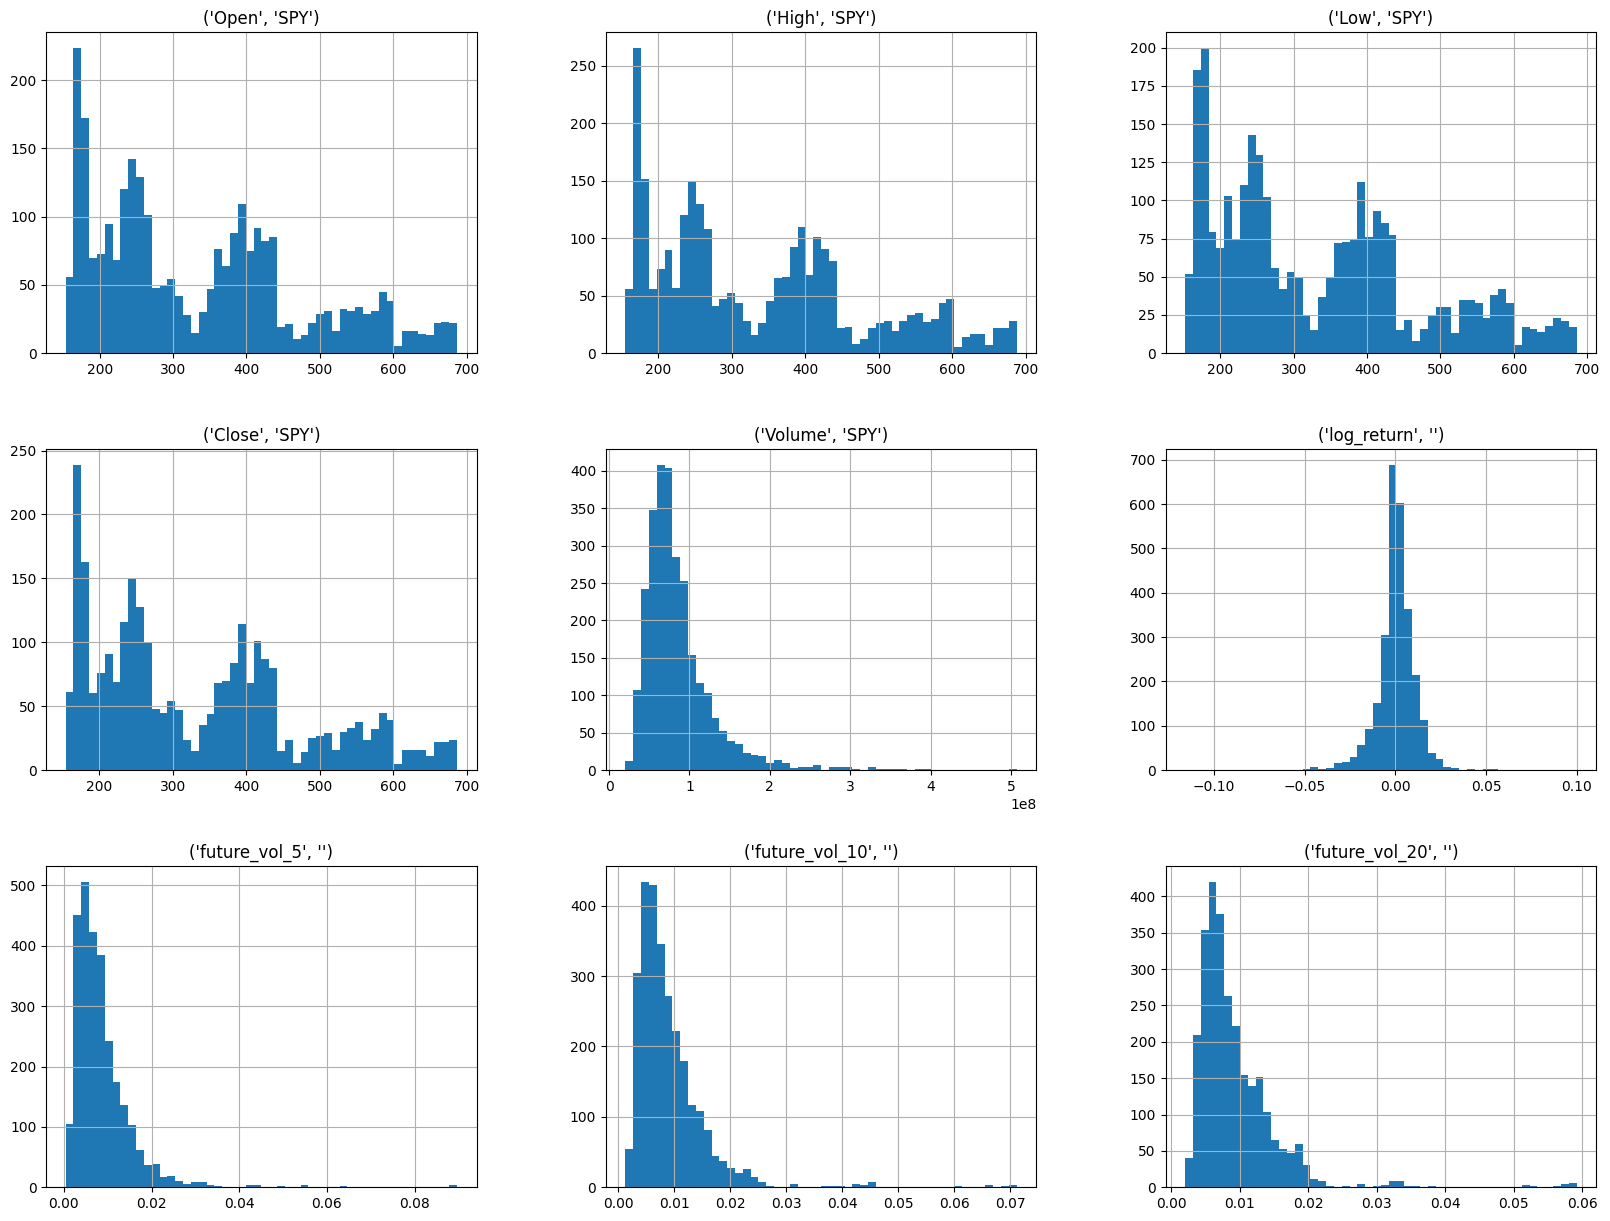

In [36]:
prices.hist(bins = 50, figsize=(20,15))
plt.show()

We can clearly see across "Open", "High", "Low", "Close" there are more prices below 450 than above, indicating that for a larger portion of the eleven odd years, these prices were more common, and it's likely that the more expensive prices are more recent. The histograms are also very similar in shape.  

We see that most of the returns are small (in either direction) with most grouping near zero.

The future volatility histograms are all positively skewed with them becoming very slightly negatively skewed as the number of days becomes larger.

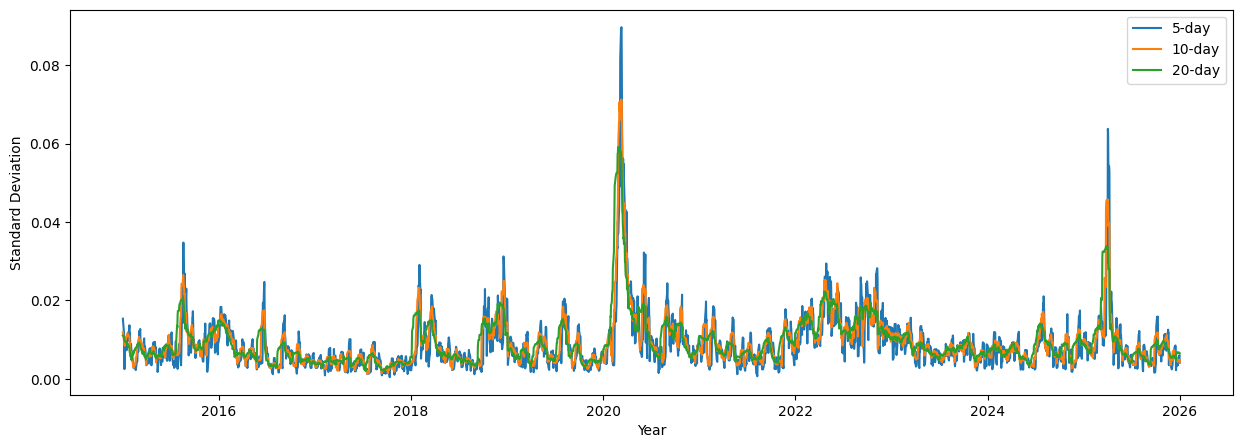

In [43]:
plt.figure(figsize=(15, 5))
plt.plot(prices.index, prices["future_vol_5"], label="5-day")
plt.plot(prices.index, prices["future_vol_10"], label="10-day")
plt.plot(prices.index, prices["future_vol_20"], label="20-day")
plt.xlabel("Year")
plt.ylabel("Standard Deviation")
plt.legend()

We see that the 20 day rolling volatility plot has less noise compared to the 10 day and five day plots. It's also interesting to see things were very volatile when COVID hit, but theres also a very big spike just after 2025 which could be related to advances and increase interest in AI.   

#### **Volaility Peaks**

In [38]:
peaks = prices["future_vol_20"].nlargest(100)

<function matplotlib.pyplot.show(close=None, block=None)>

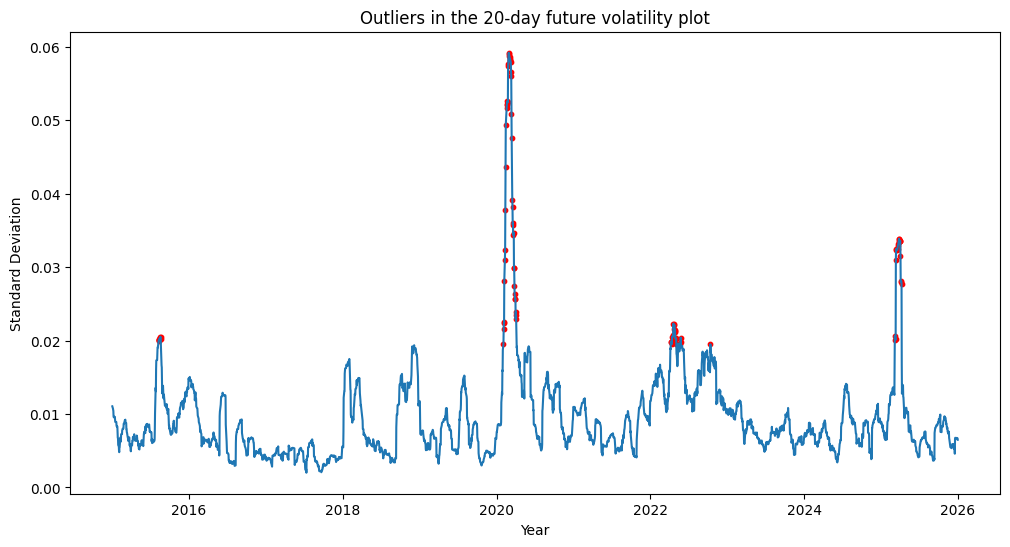

In [39]:
plt.figure(figsize = (12,6))
plt.plot(prices.index, prices["future_vol_20"])
plt.xlabel("Year")
plt.ylabel("Standard Deviation")
plt.title("Outliers in the 20-day future volatility plot")
plt.scatter(peaks.index, peaks.values, marker = "o", s=10, color = "red")
plt.show

The 100 largest standard deviation values visualised on a plot.

Picking 100 was a bit arbitrary. A more systematic way to pick the outliers would be to use standard deviation (again), where the highest values are picked out. We will focus on the highest values only, since that's where most of the outliers live. 

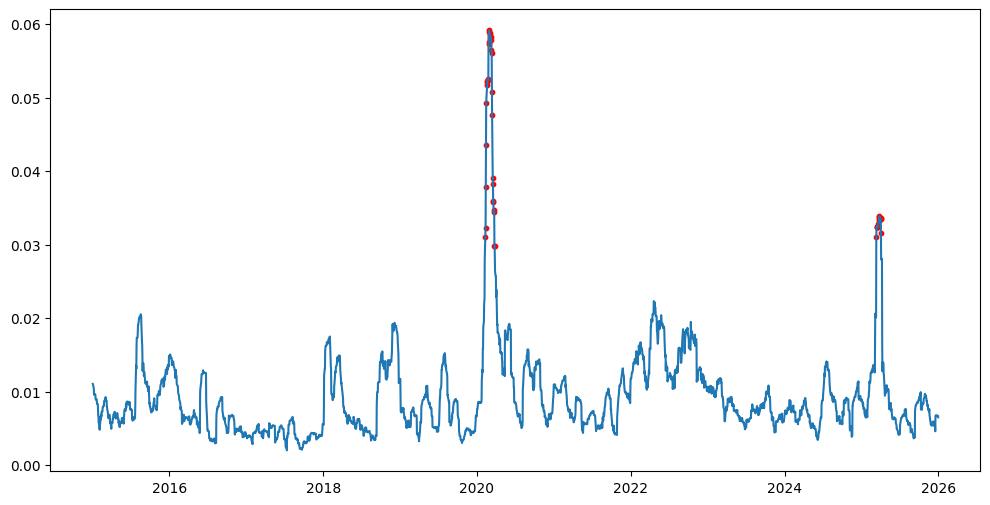

In [40]:
vol = prices["future_vol_20"]

threshold = vol.mean() + 3 * vol.std()

outliers = vol[vol > threshold]

plt.figure(figsize=(12,6))
plt.plot(prices.index, vol)

plt.scatter(
    outliers.index,
    outliers.values,
    s=10, color = "red", marker = "o"
)

plt.show()

Let's also take a look at the local peaks:

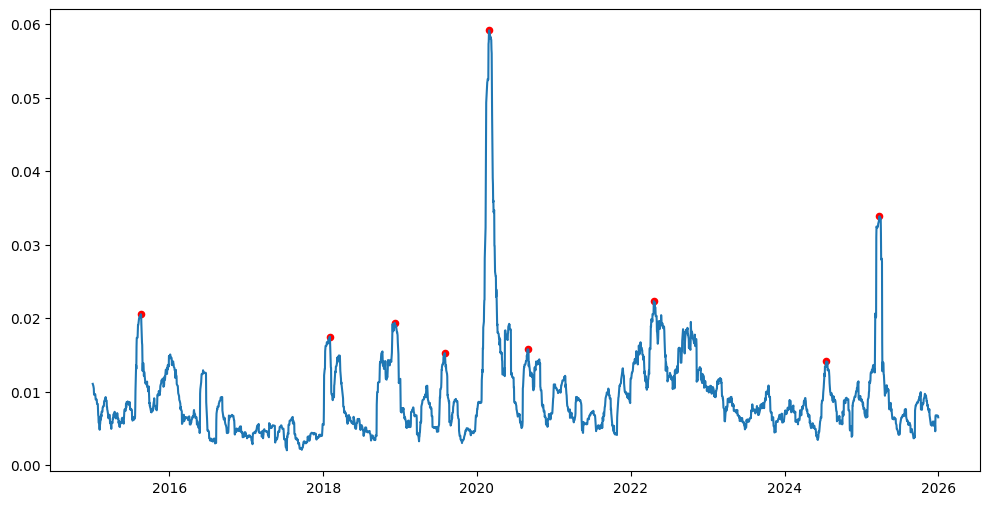

In [41]:
from scipy.signal import find_peaks

peaks, _ = find_peaks(
    prices["future_vol_20"],
    prominence=0.01  # adjust as needed
)

plt.figure(figsize=(12,6))
plt.plot(prices.index, prices["future_vol_20"])

plt.scatter(
    prices.index[peaks],
    prices["future_vol_20"].iloc[peaks], marker = "o",
    s=20, color = "red"
)

plt.show()

Although these are "outliers", these will ultimately help the model predict volatility in both chaotic and calm periods. Getting rid of these outliers will hurt our predictive ability, so we'll keep these in for now.

Based on these plots, we can also see that volatility tends to cluster, where higher than normal volatility today usually implies higher volatilty tomorrow.

#### **Volatility + Returns**

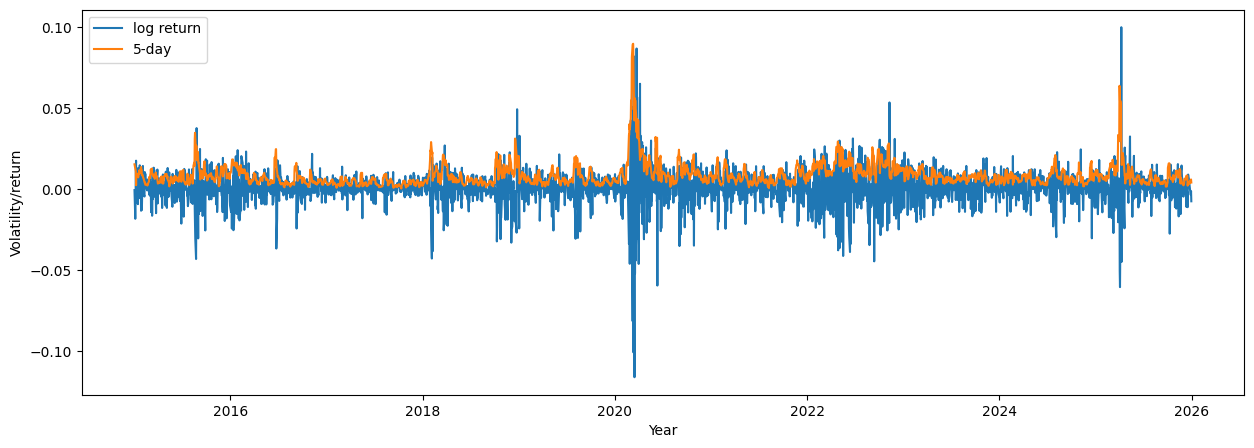

In [42]:
plt.figure(figsize=(15, 5))
plt.plot(prices.index, prices["log_return"], label = "log return")
plt.plot(prices.index, prices["future_vol_5"], label="5-day")
plt.xlabel("Year")
plt.ylabel("Volatility/return")
plt.legend()

We can confirm that higher magnitudes of returns closely resembles the magnitude of volatility. 

### **The problem definition**

Before moving any further, we will define our problems and input/output structure.

What are we actually predicting?
- future 10-day volatility
- In other words, "How volatile are things going to be over the next ten days from today?"
    - Model spits out a number e.g 0.09 ("things are going to be very volatile over the next 10 days")

Input:
- Features at time t

Output:
- Volatility value for the next ten days

Clearing up confusion:

rolling future volatility was calculated for the target variable/column to turn this project into a supervised learning problem

now model will learn from the data just like a normal regression problem, it will not be concerned with future log returns and other features, it will just make a prediction based on the features at hand.

the prediction we get will be volatility over the next ten days since thats how we calculated it initially. 